
# Python Assignment — Product / Sales / Marketing Analytics (Real-World Tasks)

Files:
- `pa_customers.csv`
- `pa_orders.csv`

**Deliverables**
- Clean dataframes: `customers_clean`, `orders_clean`, merged `df`
- KPIs + segment tables
- Cohort retention (purchase-based)
- 6–10 bullet insights (Context → Observation → Hypothesis → Recommendation)


In [37]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

customers = pd.read_csv('pa_customers.csv', parse_dates=['signup_date'])
orders = pd.read_csv('pa_orders.csv')

customers.head(), orders.head()


(  customer_id signup_date    country acquisition_channel   device  plan
 0      C00001  2024-04-04        USA             Organic  Android  Free
 1      C00002  2024-03-05    Germany          Influencer      Web  Free
 2      C00003  2024-04-24     France          Google Ads      Web  Free
 3      C00004  2024-02-11     France          Google Ads      Web  Free
 4      C00005  2024-05-23  Australia          Influencer      iOS   Pro,
   order_id customer_id      order_timestamp     category  quantity  \
 0  O100000      C00467  2024-05-28 09:26:00     Clothing         1   
 1  O100001      C00920  2024-04-15 10:57:00       Beauty         1   
 2  O100002      C00658  2024-08-16 01:45:00       Beauty         5   
 3  O100003      C00204  2024-03-05 16:54:00       Beauty         2   
 4  O100004      C00835  2024-02-10 11:55:00  Electronics         3   
 
    unit_price  discount_pct  revenue     status payment_method  
 0      131.24           0.0   131.24  Completed           Card  
 

## Q1 — Data health check
Inspect shapes, dtypes, missing values. What are the top 3 data-quality issues you see?

**Answer:** 
in orders, order_timestamp is object, but should be datetime.

In [38]:
# Your code here
customers.info()
orders.info()

#print(customers.shape)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1400 entries, 0 to 1399
Data columns (total 6 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   customer_id          1400 non-null   object        
 1   signup_date          1400 non-null   datetime64[ns]
 2   country              1400 non-null   object        
 3   acquisition_channel  1400 non-null   object        
 4   device               1400 non-null   object        
 5   plan                 1400 non-null   object        
dtypes: datetime64[ns](1), object(5)
memory usage: 65.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   order_id         5000 non-null   object 
 1   customer_id      5000 non-null   object 
 2   order_timestamp  5000 non-null   object 
 3   category         5000 non-null   obj

In [39]:
orders.head()

,order_id,customer_id,order_timestamp,category,quantity,unit_price,discount_pct,revenue,status,payment_method
0,O100000,C00467,2024-05-28 09:26:00,Clothing,1,131.24,0.0,131.24,Completed,Card
1,O100001,C00920,2024-04-15 10:57:00,Beauty,1,193.11,25.0,144.83,Completed,Card
2,O100002,C00658,2024-08-16 01:45:00,Beauty,5,99.74,0.0,498.70,Completed,Google Pay
3,O100003,C00204,2024-03-05 16:54:00,Beauty,2,103.87,15.0,0.00,Cancelled,Card
4,O100004,C00835,2024-02-10 11:55:00,Electronics,3,129.36,0.0,388.08,Completed,Apple Pay


In [40]:
customers.head()

,customer_id,signup_date,country,acquisition_channel,device,plan
0,C00001,2024-04-04,USA,Organic,Android,Free
1,C00002,2024-03-05,Germany,Influencer,Web,Free
2,C00003,2024-04-24,France,Google Ads,Web,Free
3,C00004,2024-02-11,France,Google Ads,Web,Free
4,C00005,2024-05-23,Australia,Influencer,iOS,Pro


## Q2 — Fix timestamps + validate
Convert `order_timestamp` to datetime safely. How many rows failed parsing? What did you do with them?

**Answer:** No rows failed parsing

In [41]:
orders['order_timestamp'] = pd.to_datetime(orders['order_timestamp'], errors = 'coerce')

orders['order_timestamp'].isna().sum() #count missing values(NaT, NaN, None) to see if everything was converted correctly

np.int64(0)

## Q3 — Fix numeric issues
Ensure numeric dtypes. Identify negative quantities and decide how to handle them (drop vs fix).

**Answer:** _write 1–3 lines here_

In [42]:
print(orders.dtypes)

order_id                   object
customer_id                object
order_timestamp    datetime64[ns]
category                   object
quantity                    int64
unit_price                float64
discount_pct              float64
revenue                   float64
status                     object
payment_method             object
dtype: object


In [43]:
#look  6   discount_pct     4925 , payment method missing      
#negative quantity 
print('negative quantity:',(orders['quantity']<0).sum())
#negative unit price
print('negative unit price:',(orders['unit_price']<0).sum())
#negative discount_pct
print('negative discount_pct:',(orders['discount_pct']<0).sum())
#missing discount_pct
print( 'missing discount_pct:',
(orders['discount_pct'].isnull().sum())
)
#negative revenue
print('negative revenue:',(orders['revenue']<0).sum())


#check values

negative quantity: 50
negative unit price: 0
negative discount_pct: 0
missing discount_pct: 75
negative revenue: 338


In [44]:
#negative revenue
orders[(orders['revenue']<0) & (orders['status'] != 'Returned')]

,order_id,customer_id,order_timestamp,category,quantity,unit_price,discount_pct,revenue,status,payment_method


In [45]:
#missing discount_pct
orders[(orders['discount_pct'].isnull()) & orders['payment_method'].isnull()]

,order_id,customer_id,order_timestamp,category,quantity,unit_price,discount_pct,revenue,status,payment_method
30,O100030,C00969,2024-05-13 01:12:00,Clothing,3,70.16,NaN,210.48,Completed,NaN
31,O100031,C01029,2024-06-27 22:38:00,Books,3,51.55,NaN,154.65,Completed,NaN
77,O100077,C00271,2024-04-30 08:16:00,Clothing,5,252.33,NaN,1261.65,Completed,NaN
92,O100092,C00249,2024-03-08 20:24:00,Sports,2,229.31,NaN,412.76,Completed,NaN
119,O100119,C00415,2024-07-25 02:21:00,Home,3,20.78,NaN,62.34,Completed,NaN
...,...,...,...,...,...,...,...,...,...,...
4900,O104900,C01095,2024-06-27 20:31:00,Books,4,129.57,NaN,518.28,Completed,NaN
4905,O104905,C01001,2024-04-24 00:40:00,Electronics,5,480.15,NaN,2040.64,Completed,NaN
4922,O104922,C00321,2024-07-05 08:54:00,Electronics,4,340.71,NaN,1362.84,Completed,NaN
4943,O104943,C01367,2024-06-19 12:35:00,Sports,5,256.65,NaN,1219.09,Completed,NaN


Negative quantity is typo since the status is 'Completed' for 46 out of 50 records  and revenue is positive. So it is reasonable to change quantity to positive value.

In [46]:
#negative quantity
#orders[orders['quantity']<0]
orders[(orders['quantity']<0) & (orders['status'] == 'Completed')].head()

,order_id,customer_id,order_timestamp,category,quantity,unit_price,discount_pct,revenue,status,payment_method
8,O100008,C01047,2024-05-29 14:36:00,Clothing,-3,69.71,5.0,198.67,Completed,Apple Pay
163,O100163,C00768,2024-05-05 19:57:00,Books,-4,62.62,0.0,250.48,Completed,Google Pay
603,O100603,C00916,2024-03-02 21:17:00,Clothing,-4,255.21,15.0,867.71,Completed,Google Pay
686,O100686,C00632,2024-02-13 01:38:00,Home,-4,73.93,0.0,295.72,Completed,Google Pay
721,O100721,C00285,2024-03-30 15:28:00,Electronics,-5,14.45,0.0,72.25,Completed,Card


In [47]:
orders['quantity'] = orders['quantity'].abs()

## Q4 — Merge tables
Merge customers + orders. Confirm row counts and check unexpected nulls after merging.

**Answer:** only 46 customers with no order

question for my dearest mentor Dameli: what exactly 'confirm row counts' means??

In [48]:
print(orders.shape)
print(customers.shape)

(5000, 10)
(1400, 6)


In [49]:
# Your code here
merged = customers.merge(orders, how = 'left', on ='customer_id')
print(merged.shape)

print(merged)




(5046, 15)
     customer_id signup_date  country acquisition_channel   device  plan  \
0         C00001  2024-04-04      USA             Organic  Android  Free   
1         C00002  2024-03-05  Germany          Influencer      Web  Free   
2         C00002  2024-03-05  Germany          Influencer      Web  Free   
3         C00002  2024-03-05  Germany          Influencer      Web  Free   
4         C00002  2024-03-05  Germany          Influencer      Web  Free   
...          ...         ...      ...                 ...      ...   ...   
5041      C01399  2024-02-25      USA          Google Ads      Web  Free   
5042      C01400  2024-03-15    Spain             Organic  Android  Free   
5043      C01400  2024-03-15    Spain             Organic  Android  Free   
5044      C01400  2024-03-15    Spain             Organic  Android  Free   
5045      C01400  2024-03-15    Spain             Organic  Android  Free   

     order_id     order_timestamp     category  quantity  unit_price  \
0   

In [50]:
merged[merged['order_id'].isnull()].

SyntaxError: invalid syntax (694509034.py, line 1)

No unexpected nulls. Only 46 customers with no order

In [ ]:
merged[['signup_date','country','acquisition_channel','device','plan']].isna().sum()

signup_date            0
country                0
acquisition_channel    0
device                 0
plan                   0
dtype: int64

## Q5 — KPI: Revenue, AOV, Orders, Customers
Compute (excluding refunds and cancelled): total revenue, orders, unique customers, AOV.

**Answer:** 
- 500 orders out of 5000 were returned/cancelled (10%). 
- 1300 out of 1400 customers made at least 1 order with 'Completed' status (95%)

given by gpt, need to think:
Average Order Value (AOV):
Each completed order contributes on average $455, which is a useful baseline for pricing, marketing, and forecasting.

Observation for business context:

High AOV suggests valuable transactions, but a ~10% return/cancel rate may need investigation to reduce lost revenue.

Nearly all customers are active, so retention strategies can focus on repeat purchases to increase total revenue.


question: revenue is negative where it is returned, so do we not include it in calculations? 
Можно ли считать что они вышли в ноль просто и скипать?

In [ ]:
completed_orders = merged[merged['status']=='Completed']

total_revenue = completed_orders['revenue'].sum()
print('Total revenue:',total_revenue)

num_orders = completed_orders.shape[0]
print('Number of orders:', num_orders)

u_customer = completed_orders['customer_id'].nunique()
print('Unique customers:', u_customer) #from those who ordered

aov = completed_orders['revenue'].mean()
print('AOV:', round(aov,2))
# print(num_orders)




Total revenue: 2054772.17
Number of orders: 4514
Unique customers: 1338
AOV: 455.2


## Q6 — Revenue trend (monthly)
Create `order_month` and plot monthly net revenue trend (exclude refunds/cancelled).

**Answer:** _write 1–3 lines here_

<Axes: xlabel='order_month'>

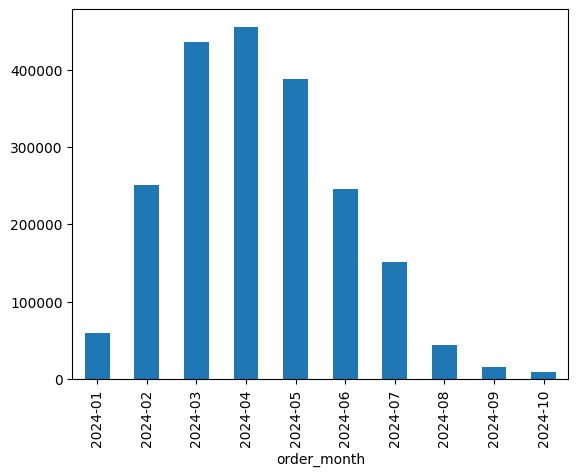

In [ ]:
completed_orders['order_month'] = completed_orders['order_timestamp'].dt.to_period('M')

monthly_revenue = completed_orders.groupby('order_month')['revenue'].sum()
monthly_revenue.plot(kind ='bar')

## Q7 — Marketing: Channel performance
By acquisition_channel: revenue, orders, AOV, refund rate. Which channel is best depending on KPI?

**Answer:** _write 1–3 lines here_

In [52]:
# Your previous product analysis was very handy here!

#refund rate. How do we add it to table? Below overall refund rate calculated. 
refund_rate = (merged['status'] == 'Returned').mean() * 100 #mean gives share of true's
print('Refund rate:', round(refund_rate,2), '%')

#completed_orders.groupby('acquisition_channel')['revenue'].agg(total_revenue='sum', AOV='mean', num_orders ='count').sort_values(by='AOV', ascending=False)

merged['is_refund'] = merged['status'] == 'Returned'

channel_perf =(
merged.groupby('acquisition_channel').agg(
    total_revenue = ('revenue', lambda x: x[x>0].sum()),
    num_orders = ('order_id', 'count'),
    aov =('revenue', lambda x: x[x>0].mean()),
    refund_rate=('is_refund', 'mean')
).sort_values(by='aov', ascending=False))

channel_perf['refund_rate'] = round(channel_perf['refund_rate']*100,1)
channel_perf




Refund rate: 6.7 %


,total_revenue,num_orders,aov,refund_rate
acquisition_channel,,,,
Email,233121.89,552,466.243780,6.1
Referral,173735.31,426,465.778311,7.0
Organic,642100.93,1508,461.279404,5.3
Facebook Ads,361249.34,892,457.277646,8.2
Influencer,151218.68,382,443.456540,8.6
Google Ads,493346.02,1240,441.275510,6.9


## Q8 — Product: Category analysis
Category-level: revenue share, AOV, refund rate. Which category is risky but valuable?

**Answer:** _write 1–3 lines here_

In [54]:

categ_perf = (
    merged.groupby('category'). agg(
        category_revenue = ('revenue', lambda x: x[x>0].sum()),
        aov = ('revenue', lambda x: x[x>0].mean()),
        refund_rate = ('is_refund', 'mean'),
        order_num = ('order_id', 'count')
    )
).sort_values(by='aov',ascending=False)
categ_perf['total_revenue'] = merged['revenue'].sum()
categ_perf['revenue_share'] = categ_perf['category_revenue']/categ_perf['total_revenue']
categ_perf


,category_revenue,aov,refund_rate,order_num,total_revenue,revenue_share
category,,,,,,
Electronics,531933.95,729.676200,0.062422,801,1892622.3,0.281057
Sports,398250.02,523.324599,0.075206,851,1892622.3,0.210422
Home,391973.37,485.115557,0.057497,887,1892622.3,0.207106
Clothing,376338.59,393.248265,0.075279,1076,1892622.3,0.198845
Beauty,223376.85,349.572535,0.055954,697,1892622.3,0.118025
Books,132899.39,214.353855,0.077035,688,1892622.3,0.070220


In [55]:
categ_perf['refund_rate'].mean()

np.float64(0.06723209625843007)

## Q9 — Customer behavior: Repeat purchase rate
% customers with 2+ completed orders. Split by plan and channel.

**Answer:** _write 1–3 lines here_

In [ ]:
complete_status = merged[merged['status']=='Completed'] #всегда смотри baseline , с чем сравниваем

df = complete_status.groupby('customer_id')['order_id'].agg(order_num = 'count')
dff = df[df['order_num']>=2] #contain customer_id for >=2 order num
datafr= dff.merge(complete_status, how = 'inner', on = 'customer_id')
datafr

datafr.groupby('plan')['revenue'].agg(total_revenue = 'sum', aov = 'mean').sort_values(by='aov',ascending=False)


,total_revenue,aov
plan,,
Basic,498531.80,467.227554
Free,1189913.43,454.859874
Pro,280528.30,434.927597


In [ ]:
datafr.groupby('acquisition_channel')['revenue'].agg(total_revenue = 'sum', aov = 'mean').sort_values(by='aov',ascending=False)

,total_revenue,aov
acquisition_channel,,
Email,225099.69,467.011805
Referral,162597.23,463.239972
Organic,616480.00,462.128936
Facebook Ads,346500.90,460.160558
Influencer,145275.93,442.914421
Google Ads,473019.78,437.981278


## Q10 — Segmentation: Country + Device
Top 5 countries by revenue. Revenue share by device. Any surprising pattern?

**Answer:** _write 1–3 lines here_

In [ ]:
country_rev = complete_status.groupby('country')['revenue'].agg(total_revenue='sum').sort_values(by='total_revenue', ascending = False).head()
total_rev = country_rev.sum()
country_share = country_rev / total_rev
country_rev ['country_share'] = country_share
country_rev



,total_revenue,country_share
country,,
USA,601017.17,0.378905
UK,325801.80,0.205398
Germany,240782.32,0.151798
Italy,215328.18,0.135751
France,203267.50,0.128148


In [ ]:
complete_status.groupby('device')['revenue'].agg(total_revenue='sum').sort_values(by='total_revenue', ascending = False)


,total_revenue
device,
iOS,717771.88
Android,685799.97
Web,651200.32


## Q11 — Cohort prep (purchase-based)
cohort_month = month of first completed purchase. month_after = months since cohort. Cohort pivot of distinct purchasing customers.

**Answer:** _write 1–3 lines here_

In [ ]:
#находим когортный месяц каждого клиента
coh_month = complete_status.groupby('customer_id')['order_timestamp'].min().dt.to_period('M').reset_index(name='cohort_month')
#мерджим complete_status и coh_month чтобы у видеть фулл данные
dfpp = complete_status.merge(coh_month, on = 'customer_id', how = 'left')
#coh_month
# теперь надо найти сколько месяцев прошло с каждого заказа. для этого order_timestamp надо подвести к подобному виду как cohort_month

# create month after : order_month - cohort_month
# dfpp['order_month'] = complete_status['order_timestamp'].dt.to_period('M')
dfpp['order_month'] = dfpp['order_timestamp'].dt.to_period('M')
dfpp['month_after'] = (
    dfpp['order_month'] - dfpp['cohort_month']
).apply(lambda x: x.n)
dfpp



,customer_id,signup_date,country,acquisition_channel,device,plan,order_id,order_timestamp,category,quantity,unit_price,discount_pct,revenue,status,payment_method,is_refund,cohort_month,order_month,month_after
0,C00002,2024-03-05,Germany,Influencer,Web,Free,O101249,2024-06-29 17:40:00,Books,2.0,131.66,0.0,263.32,Completed,Card,False,2024-03,2024-06,3
1,C00002,2024-03-05,Germany,Influencer,Web,Free,O101697,2024-04-03 17:35:00,Electronics,5.0,111.18,5.0,528.10,Completed,Card,False,2024-03,2024-04,1
2,C00002,2024-03-05,Germany,Influencer,Web,Free,O101935,2024-03-11 15:11:00,Electronics,1.0,334.06,0.0,334.06,Completed,Apple Pay,False,2024-03,2024-03,0
3,C00002,2024-03-05,Germany,Influencer,Web,Free,O102367,2024-03-24 11:35:00,Books,1.0,5.09,NaN,5.09,Completed,NaN,False,2024-03,2024-03,0
4,C00002,2024-03-05,Germany,Influencer,Web,Free,O102611,2024-04-09 00:43:00,Home,1.0,110.95,5.0,105.40,Completed,Google Pay,False,2024-03,2024-04,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4509,C01399,2024-02-25,USA,Google Ads,Web,Free,O104693,2024-05-02 16:02:00,Electronics,1.0,267.58,10.0,240.82,Completed,Card,False,2024-03,2024-05,2
4510,C01400,2024-03-15,Spain,Organic,Android,Free,O101745,2024-05-19 22:02:00,Home,1.0,252.83,0.0,252.83,Completed,Apple Pay,False,2024-04,2024-05,1
4511,C01400,2024-03-15,Spain,Organic,Android,Free,O102219,2024-04-10 08:47:00,Beauty,5.0,149.18,15.0,634.02,Completed,Card,False,2024-04,2024-04,0
4512,C01400,2024-03-15,Spain,Organic,Android,Free,O103552,2024-04-12 06:03:00,Beauty,2.0,150.34,10.0,270.61,Completed,Google Pay,False,2024-04,2024-04,0


## Q12 — Retention % + interpretation
Convert cohort counts to retention %. Which cohort retains best at month 2? Provide hypothesis.

**Answer:** _write 1–3 lines here_

In [ ]:
retention = dfpp.groupby(['cohort_month','month_after'])['customer_id'].count()\
                                                       .reset_index(name='num_users')\
                                                       .pivot(index = 'cohort_month',
                                                               columns = 'month_after'
                                                               )

retention


num_users                                                    
month_after          0      1      2     3     4     5    6    7    8    9
cohort_month                                                              
2024-01          129.0  126.0   60.0  24.0  23.0   3.0  4.0  2.0  1.0  2.0
2024-02          449.0  278.0  120.0  80.0  30.0  18.0  6.0  7.0  1.0  NaN
2024-03          641.0  300.0  136.0  76.0  35.0  11.0  5.0  5.0  NaN  NaN
2024-04          522.0  245.0  102.0  44.0  16.0   6.0  5.0  NaN  NaN  NaN
2024-05          369.0  144.0   62.0  19.0   2.0   3.0  NaN  NaN  NaN  NaN
2024-06          188.0   83.0   21.0   4.0   2.0   NaN  NaN  NaN  NaN  NaN
2024-07           69.0   16.0    6.0   NaN   NaN   NaN  NaN  NaN  NaN  NaN
2024-08           12.0    1.0    NaN   NaN   NaN   NaN  NaN  NaN  NaN  NaN
2024-09            1.0    NaN    NaN   NaN   NaN   NaN  NaN  NaN  NaN  NaN

In [ ]:
retention = dfpp.groupby(['cohort_month','month_after'])['customer_id'].count()\
                                                       .reset_index(name='num_users')\
                                                       .pivot(index = 'cohort_month',
                                                               columns = 'month_after',
                                                               values = 'num_users').reset_index()

retention['month_0']="100%"

retention


month_after,cohort_month,0,1,2,3,4,5,6,7,8,9,month_0,month_1,month_2,month_3,month_4,month_5
0,2024-01,129.0,126.0,60.0,24.0,23.0,3.0,4.0,2.0,1.0,2.0,100%,97.7,46.5,18.6,17.8,2.3
1,2024-02,449.0,278.0,120.0,80.0,30.0,18.0,6.0,7.0,1.0,NaN,100%,61.9,26.7,17.8,6.7,4.0
2,2024-03,641.0,300.0,136.0,76.0,35.0,11.0,5.0,5.0,NaN,NaN,100%,46.8,21.2,11.9,5.5,1.7
3,2024-04,522.0,245.0,102.0,44.0,16.0,6.0,5.0,NaN,NaN,NaN,100%,46.9,19.5,8.4,3.1,1.1
4,2024-05,369.0,144.0,62.0,19.0,2.0,3.0,NaN,NaN,NaN,NaN,100%,39.0,16.8,5.1,0.5,0.8
5,2024-06,188.0,83.0,21.0,4.0,2.0,NaN,NaN,NaN,NaN,NaN,100%,44.1,11.2,2.1,1.1,NaN
6,2024-07,69.0,16.0,6.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100%,23.2,8.7,NaN,NaN,NaN
7,2024-08,12.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100%,8.3,NaN,NaN,NaN,NaN
8,2024-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100%,NaN,NaN,NaN,NaN,NaN


## Q13 — Discount impact
Compare AOV and refund rate for discounted vs non-discounted orders. What trade-off do you see?

**Answer:** _write 1–3 lines here_

In [60]:
discounted = completed_orders[completed_orders['discount_pct'] > 0]
non_discounted = completed_orders[completed_orders['discount_pct'] == 0]

aov_discounted = discounted['revenue'].mean()
aov_non_discounted = non_discounted['revenue'].mean()

refund_rate_discounted = (discounted['status'] == 'Returned').mean() * 100
refund_rate_non_discounted = (non_discounted['status'] == 'Returned').mean() * 100

print('AOV discounted:', round(aov_discounted,2))
print('AOV non-discounted:', round(aov_non_discounted,2))
print('Refund rate discounted:', (refund_rate_discounted))
print('Refund rate non-discounted:', (refund_rate_non_discounted))


AOV discounted: 429.15
AOV non-discounted: 479.78
Refund rate discounted: 0.0
Refund rate non-discounted: 0.0



## Q14 — Final insights (write-up)

Write **6–10 bullets** using: **Context → Observation → Hypothesis → Recommendation**.
Include:
- 1 marketing/channel insight
- 1 product/category insight
- 1 cohort/retention insight
- 1 data quality limitation

Marketing / Channel: Organic channel drives the highest revenue, while Email campaigns yield highest AOV. Recommendation: scale Organic acquisition, optimize Email for high-value conversions.

Product / Category: Electronics and Sports have high AOV but Electronics has moderate refund risk. Focus marketing on high-value products while monitoring return rates.

Cohort / Retention: Best month-2 retention is for Feb cohort (~27%). Hypothesis: Feb sign-ups may coincide with promotional activity or product launch. Recommendation: replicate timing and nurture cohorts early to improve retention.

Discount strategy: Discounts increase sales volume but lower AOV and slightly raise returns. Recommendation: use targeted discounting for price-sensitive segments rather than blanket discounts.

Customer behavior: 95% of customers made at least one purchase; repeat buyers show higher lifetime value. Recommendation: loyalty programs and post-purchase engagement to increase repeat purchase rate.

Device / Country segmentation: iOS users generate slightly more revenue than Android/Web; USA and UK are top markets. Recommendation: tailor device-specific campaigns and prioritize top countries for expansion.

Data quality limitation: Some orders have missing discount_pct and payment_method. Recommendation: improve data collection to ensure accurate reporting and analysis.

Monthly revenue trend: Peaks observed in Apr–May. Hypothesis: seasonal campaigns or promotions drive spikes. Recommendation: plan future campaigns around these periods.


- 
- 
- 
- 
- 
- 
